In [264]:
import pandas as pd
import numpy as np
import os
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
import scipy as sp
import holidays
from collections import deque
from lightgbm import LGBMRegressor
import joblib

In [265]:
path = "../dataset/household_power_consumption.csv"

df = pd.read_csv(path, sep=';', low_memory=False)

# Análise Exploratória

In [266]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


Os dados se encontram no formato de string, logo seleciono as colunas e trato-as para formato numérico.

In [267]:
cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2'
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [268]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [269]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [270]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Removendo variáveis

In [271]:
df = df.drop(columns=['Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'])

In [272]:
df = df.dropna()

In [273]:
df.isnull().sum()

Date                   0
Time                   0
Global_active_power    0
dtype: int64

In [274]:
amostra = df.sample(n=1000, random_state=42)

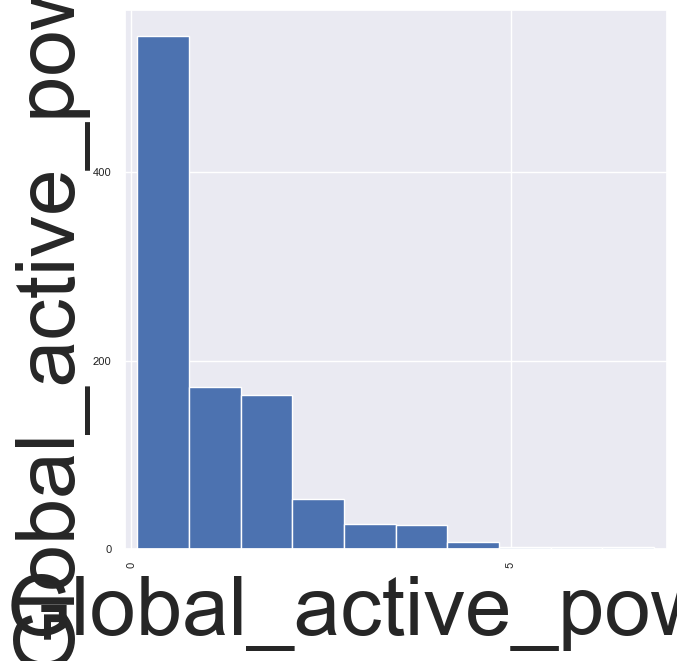

In [275]:
df_without_timestamp = amostra.drop(columns=["Date", "Time"])
scatter_matrix(df_without_timestamp, figsize=(7,7))
pyplot.show()   

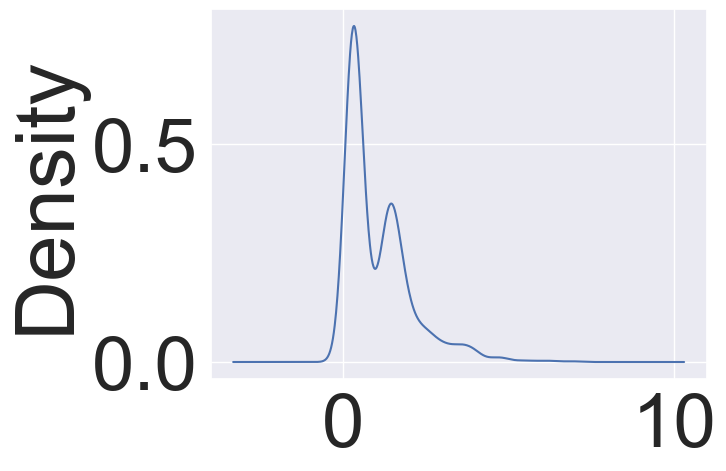

In [276]:
amostra['Global_active_power'].plot(kind='kde')
# amostra.plot.scatter(x='use', y='dataid', colormap='viridis')
pyplot.show()


## Agrupando por data

In [277]:
df_transformated = df.copy()
# df_aggregated = df.sample(100000)
# df_aggregated = df[0:5000000]

### Convertee date e time para formato timestamp

In [278]:
aggregate_freq = "1D"

In [279]:
# juntar data + hora
df_transformated["datetime"] = (
    pd.to_datetime(
        df_transformated["Date"] + " " + df_transformated["Time"],
        format="%d/%m/%Y %H:%M:%S"
    )
    .dt.tz_localize(
        "Europe/Paris",
        ambiguous="NaT",
        nonexistent="shift_forward"
    )
)
# converter para UTC
df_transformated = df_transformated.dropna(subset=["datetime"])

df_transformated = df_transformated.drop(columns=['Date', 'Time'])

In [280]:
df_transformated.head()

,Global_active_power,datetime
0,4.216,2006-12-16 17:24:00+01:00
1,5.360,2006-12-16 17:25:00+01:00
2,5.374,2006-12-16 17:26:00+01:00
3,5.388,2006-12-16 17:27:00+01:00
4,3.666,2006-12-16 17:28:00+01:00


## Testando biblioteca de feriados

In [281]:
fr_holidays = holidays.FR()

In [282]:
"2025-01-01" in fr_holidays
fr_holidays.get("2025-01-01")

"Jour de l'an"

In [283]:
df_transformated.iloc[0]["datetime"]

Timestamp('2006-12-16 17:24:00+0100', tz='Europe/Paris')

In [284]:
df_transformated.head()

,Global_active_power,datetime
0,4.216,2006-12-16 17:24:00+01:00
1,5.360,2006-12-16 17:25:00+01:00
2,5.374,2006-12-16 17:26:00+01:00
3,5.388,2006-12-16 17:27:00+01:00
4,3.666,2006-12-16 17:28:00+01:00


## Gerando as features

In [285]:
features = [
    "today",
    "lag_1",
    "lag_2",
    "lag_3",

    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",

    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",

    "date"

    # "days_since_start",
    # "valid_lags"
]

newdf = pd.DataFrame(columns=features)

In [286]:
df_transformated.head()

,Global_active_power,datetime
0,4.216,2006-12-16 17:24:00+01:00
1,5.360,2006-12-16 17:25:00+01:00
2,5.374,2006-12-16 17:26:00+01:00
3,5.388,2006-12-16 17:27:00+01:00
4,3.666,2006-12-16 17:28:00+01:00


In [287]:
df_transformated["datetime"] = pd.to_datetime(df_transformated["datetime"])

df_transformated = df_transformated.set_index("datetime")

# Revisar valores em branco
df_transformated["energy_kwh"] = (
    df_transformated["Global_active_power"] / 60
)

df_daily = (
    df_transformated
    .resample("D")["energy_kwh"]
    .sum()
    .to_frame()
)

In [288]:
df_daily.head()

,energy_kwh
datetime,
2006-12-16 00:00:00+01:00,20.152933
2006-12-17 00:00:00+01:00,56.507667
2006-12-18 00:00:00+01:00,36.730433
2006-12-19 00:00:00+01:00,27.769900
2006-12-20 00:00:00+01:00,37.095800


In [289]:
df_month = df_daily.resample("MS").sum()
df_month.head()

,energy_kwh
datetime,
2006-12-01 00:00:00+01:00,696.888033
2007-01-01 00:00:00+01:00,1150.197700
2007-02-01 00:00:00+01:00,941.481433
2007-03-01 00:00:00+01:00,981.036533
2007-04-01 00:00:00+02:00,586.357767


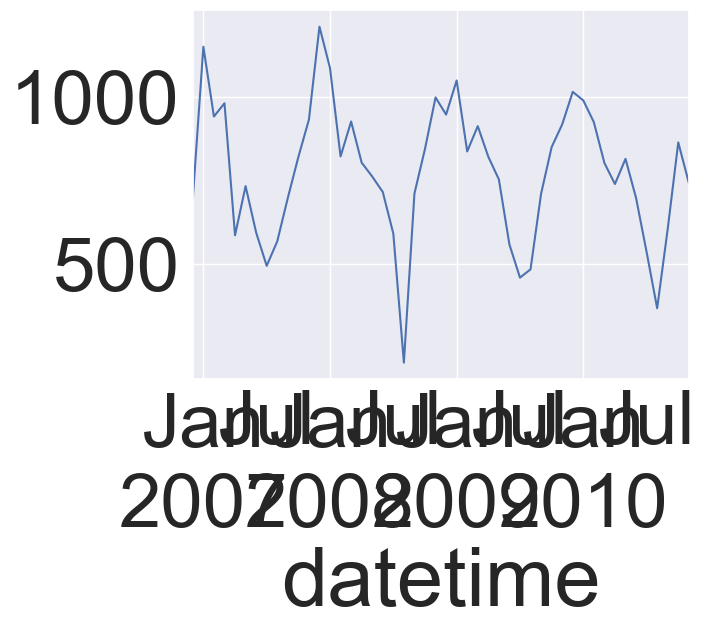

In [290]:
df_month["energy_kwh"].plot()
pyplot.show()

In [291]:

lags = np.full(6, np.nan)
rolling_mean_7 = np.nan
rolling_mean_30 = np.nan
rolling_std_7 = np.nan
days_since_start = 0
valid_tags = 1
last_30_values = deque(([np.nan] * 30), maxlen=30)
Y = None

day_of_week = None
month = None
is_weekend = None

# Pega o primeiro elemento e o remove do grupo
first = df_daily.iloc[0]
grupo = df_daily.iloc[1:]
print(grupo.iloc[0])

last_30_values.append(first.energy_kwh)
lags[0] = first.energy_kwh # Dia anterior

for localminute, row in grupo.iterrows():
    lags[1] = last_30_values[28] # Dia -2
    lags[2] = last_30_values[27] # Dia -3
    lags[3] = last_30_values[26] # Dia -7
    lags[4] = last_30_values[23] # Dia -14
    lags[5] = last_30_values[0] # Dia -30

    rolling_mean_7 = np.mean(list(last_30_values)[-7:])
    rolling_mean_30 = np.mean(last_30_values)
    rolling_std_7 = np.std(list(last_30_values)[-7:])

    days_since_start += 1

    valid_tags = np.sum(~np.isnan(lags))

    day_of_week = localminute.dayofweek
    month = localminute.month
    is_weekend = day_of_week >= 5
    is_holiday = localminute in fr_holidays


    newdf.loc[len(newdf)] = {
        "today": row['energy_kwh'],
        "lag_1": lags[0],
        "lag_2": lags[1],
        "lag_3": lags[2],
        "lag_7": lags[3],
        "lag_14": lags[4],
        "lag_30": lags[5],
        "rolling_mean_7": rolling_mean_7,
        "rolling_mean_30": rolling_mean_30,
        "rolling_std_7": rolling_std_7,
        "day_of_week": day_of_week,
        "month": month,
        "is_weekend": is_weekend,
        "date": localminute.to_pydatetime(),
        "is_holiday": is_holiday
    }

    last_30_values.append(row['energy_kwh'])
    Y = row['energy_kwh']
    print(lags)
    lags[0] = row['energy_kwh']

energy_kwh    56.507667
Name: 2006-12-17 00:00:00+01:00, dtype: float64
[20.15293333         nan         nan         nan         nan         nan]
[56.50766667 20.15293333         nan         nan         nan         nan]
[36.73043333 56.50766667 20.15293333         nan         nan         nan]
[27.7699     36.73043333 56.50766667 20.15293333         nan         nan]
[37.0958     27.7699     36.73043333 56.50766667         nan         nan]
[28.6104     37.0958     27.7699     36.73043333         nan         nan]
[39.0223     28.6104     37.0958     27.7699     20.15293333         nan]
[79.55643333 39.0223     28.6104     37.0958     56.50766667         nan]
[42.5002     79.55643333 39.0223     28.6104     36.73043333         nan]
[45.71866667 42.5002     79.55643333 39.0223     27.7699             nan]
[65.5685     45.71866667 42.5002     79.55643333 37.0958             nan]
[25.47933333 65.5685     45.71866667 42.5002     28.6104             nan]
[34.54396667 25.47933333 65.5685     45.

In [292]:
df_daily.head(8)

,energy_kwh
datetime,
2006-12-16 00:00:00+01:00,20.152933
2006-12-17 00:00:00+01:00,56.507667
2006-12-18 00:00:00+01:00,36.730433
2006-12-19 00:00:00+01:00,27.769900
2006-12-20 00:00:00+01:00,37.095800
2006-12-21 00:00:00+01:00,28.610400
2006-12-22 00:00:00+01:00,39.022300
2006-12-23 00:00:00+01:00,79.556433


In [293]:
newdf = newdf.dropna()
newdf

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday,date
29,35.811300,50.130267,53.113567,24.354933,37.586567,37.356000,20.152933,38.515081,40.528158,9.348369,0,1,False,False,2007-01-15 00:00:00+01:00
30,28.106733,35.811300,50.130267,53.113567,24.354933,31.150900,56.507667,38.294410,41.050103,9.391258,1,1,False,False,2007-01-16 00:00:00+01:00
31,47.461467,28.106733,35.811300,50.130267,53.113567,35.913333,36.730433,37.859529,40.103406,9.774641,2,1,False,False,2007-01-17 00:00:00+01:00
32,30.357700,47.461467,28.106733,35.811300,50.130267,37.586567,27.769900,39.509262,40.461107,10.268978,3,1,False,False,2007-01-18 00:00:00+01:00
33,24.674000,30.357700,47.461467,28.106733,35.811300,24.354933,37.095800,38.476567,40.547367,10.762053,4,1,False,False,2007-01-19 00:00:00+01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,34.025600,15.015167,36.616767,26.173333,27.535867,29.123033,38.220600,26.570548,28.071190,5.904988,0,11,False,False,2010-11-22 00:00:00+01:00
1437,26.292267,34.025600,15.015167,36.616767,26.173333,25.162467,39.842467,27.270914,27.931357,6.433298,1,11,False,False,2010-11-23 00:00:00+01:00
1438,29.937467,26.292267,34.025600,15.015167,36.616767,26.367200,19.388200,27.432314,27.479683,6.392418,2,11,False,False,2010-11-24 00:00:00+01:00
1439,23.852733,29.937467,26.292267,34.025600,15.015167,27.535867,15.765067,27.942352,27.831326,6.429413,3,11,False,False,2010-11-25 00:00:00+01:00


In [294]:
newdf.head(8)

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday,date
29,35.811300,50.130267,53.113567,24.354933,37.586567,37.356000,20.152933,38.515081,40.528158,9.348369,0,1,False,False,2007-01-15 00:00:00+01:00
30,28.106733,35.811300,50.130267,53.113567,24.354933,31.150900,56.507667,38.294410,41.050103,9.391258,1,1,False,False,2007-01-16 00:00:00+01:00
31,47.461467,28.106733,35.811300,50.130267,53.113567,35.913333,36.730433,37.859529,40.103406,9.774641,2,1,False,False,2007-01-17 00:00:00+01:00
32,30.357700,47.461467,28.106733,35.811300,50.130267,37.586567,27.769900,39.509262,40.461107,10.268978,3,1,False,False,2007-01-18 00:00:00+01:00
33,24.674000,30.357700,47.461467,28.106733,35.811300,24.354933,37.095800,38.476567,40.547367,10.762053,4,1,False,False,2007-01-19 00:00:00+01:00
34,52.228867,24.674000,30.357700,47.461467,28.106733,53.113567,28.610400,38.522148,40.133307,10.702659,5,1,True,False,2007-01-20 00:00:00+01:00
35,56.787700,52.228867,24.674000,30.357700,47.461467,50.130267,39.022300,38.395762,40.920589,10.533492,6,1,True,False,2007-01-21 00:00:00+01:00
36,36.341567,56.787700,52.228867,24.674000,30.357700,35.811300,79.556433,39.346824,41.512769,11.777183,0,1,False,False,2007-01-22 00:00:00+01:00


In [295]:
# Drop de colunas para teste
newdf = newdf.drop(columns=["is_weekend", "is_holiday"])

In [296]:
newdf = newdf.sort_values(by="date")

In [297]:
randomized_df = newdf.sample(frac=1, random_state=42)
randomized_df.head()

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,date
770,47.394400,36.679500,31.842267,20.622600,28.990567,52.569900,20.395533,32.571867,31.567090,9.288358,6,1,2009-01-25 00:00:00+01:00
894,20.714100,19.662267,25.738200,22.294567,22.568267,17.913433,27.744667,22.164257,24.916906,2.644891,4,5,2009-05-29 00:00:00+02:00
368,32.495967,36.600867,43.719900,29.951100,46.036967,30.795767,34.930933,37.947524,35.590406,6.544235,3,12,2007-12-20 00:00:00+01:00
221,15.408333,7.876000,13.754733,16.516967,22.929567,11.298100,15.748467,15.507600,17.064097,4.610767,3,7,2007-07-26 00:00:00+02:00
232,18.162000,13.118300,19.083167,17.722733,16.990267,7.780267,22.636767,15.129414,15.886224,3.642426,0,8,2007-08-06 00:00:00+02:00


In [298]:
# Separar em 75% train, 12.5% val, 12.5% test (baseado em proporções)
n = len(randomized_df)
train_size = int(0.75 * n)
val_size = int(0.125 * n)

train_rand = randomized_df.iloc[:train_size].copy()
val_rand = randomized_df.iloc[train_size:train_size + val_size].copy()
test_rand = randomized_df.iloc[train_size + val_size:].copy()

train_rand.shape, val_rand.shape, test_rand.shape

((1059, 13), (176, 13), (177, 13))

In [299]:
train = newdf[newdf["date"] < "2009-01-01"]

val = newdf[
    (newdf["date"] >= "2009-01-01") &
    (newdf["date"] < "2010-01-01")
]

test = newdf[newdf["date"] >= "2010-01-01"]

In [300]:
train = train_rand
val = val_rand
test = test_rand

In [301]:
train.shape, val.shape, test.shape

((1059, 13), (176, 13), (177, 13))

In [302]:
X_train = train.drop(columns=["today", "date"])
y_train = train["today"]

X_val = val.drop(columns=["today", "date"])
y_val = val["today"]

X_test = test.drop(columns=["today", "date"])
y_test = test["today"]

In [303]:
X_train.head()

,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month
770,36.679500,31.842267,20.622600,28.990567,52.569900,20.395533,32.571867,31.567090,9.288358,6,1
894,19.662267,25.738200,22.294567,22.568267,17.913433,27.744667,22.164257,24.916906,2.644891,4,5
368,36.600867,43.719900,29.951100,46.036967,30.795767,34.930933,37.947524,35.590406,6.544235,3,12
221,7.876000,13.754733,16.516967,22.929567,11.298100,15.748467,15.507600,17.064097,4.610767,3,7
232,13.118300,19.083167,17.722733,16.990267,7.780267,22.636767,15.129414,15.886224,3.642426,0,8


In [304]:
y_train.head()

770    47.394400
894    20.714100
368    32.495967
221    15.408333
232    18.162000
Name: today, dtype: float64

In [305]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2315
[LightGBM] [Info] Number of data points in the train set: 1059, number of used features: 11
[LightGBM] [Info] Start training from score 25.421921


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1000,
              random_state=42, subsample=0.8)

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

def plotImp(model, X , num = 20, fig_size = (40, 20)):
    feature_imp = pd.DataFrame({'Value':model.feature_importances_,'Feature':X.columns})
    plt.figure(figsize=fig_size)
    sns.set(font_scale = 5)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", 
                                                        ascending=False)[0:num])
    plt.title('LightGBM Features (avg over folds)')
    plt.tight_layout()
    # plt.savefig('lgbm_importances-01.png')
    plt.show()
   

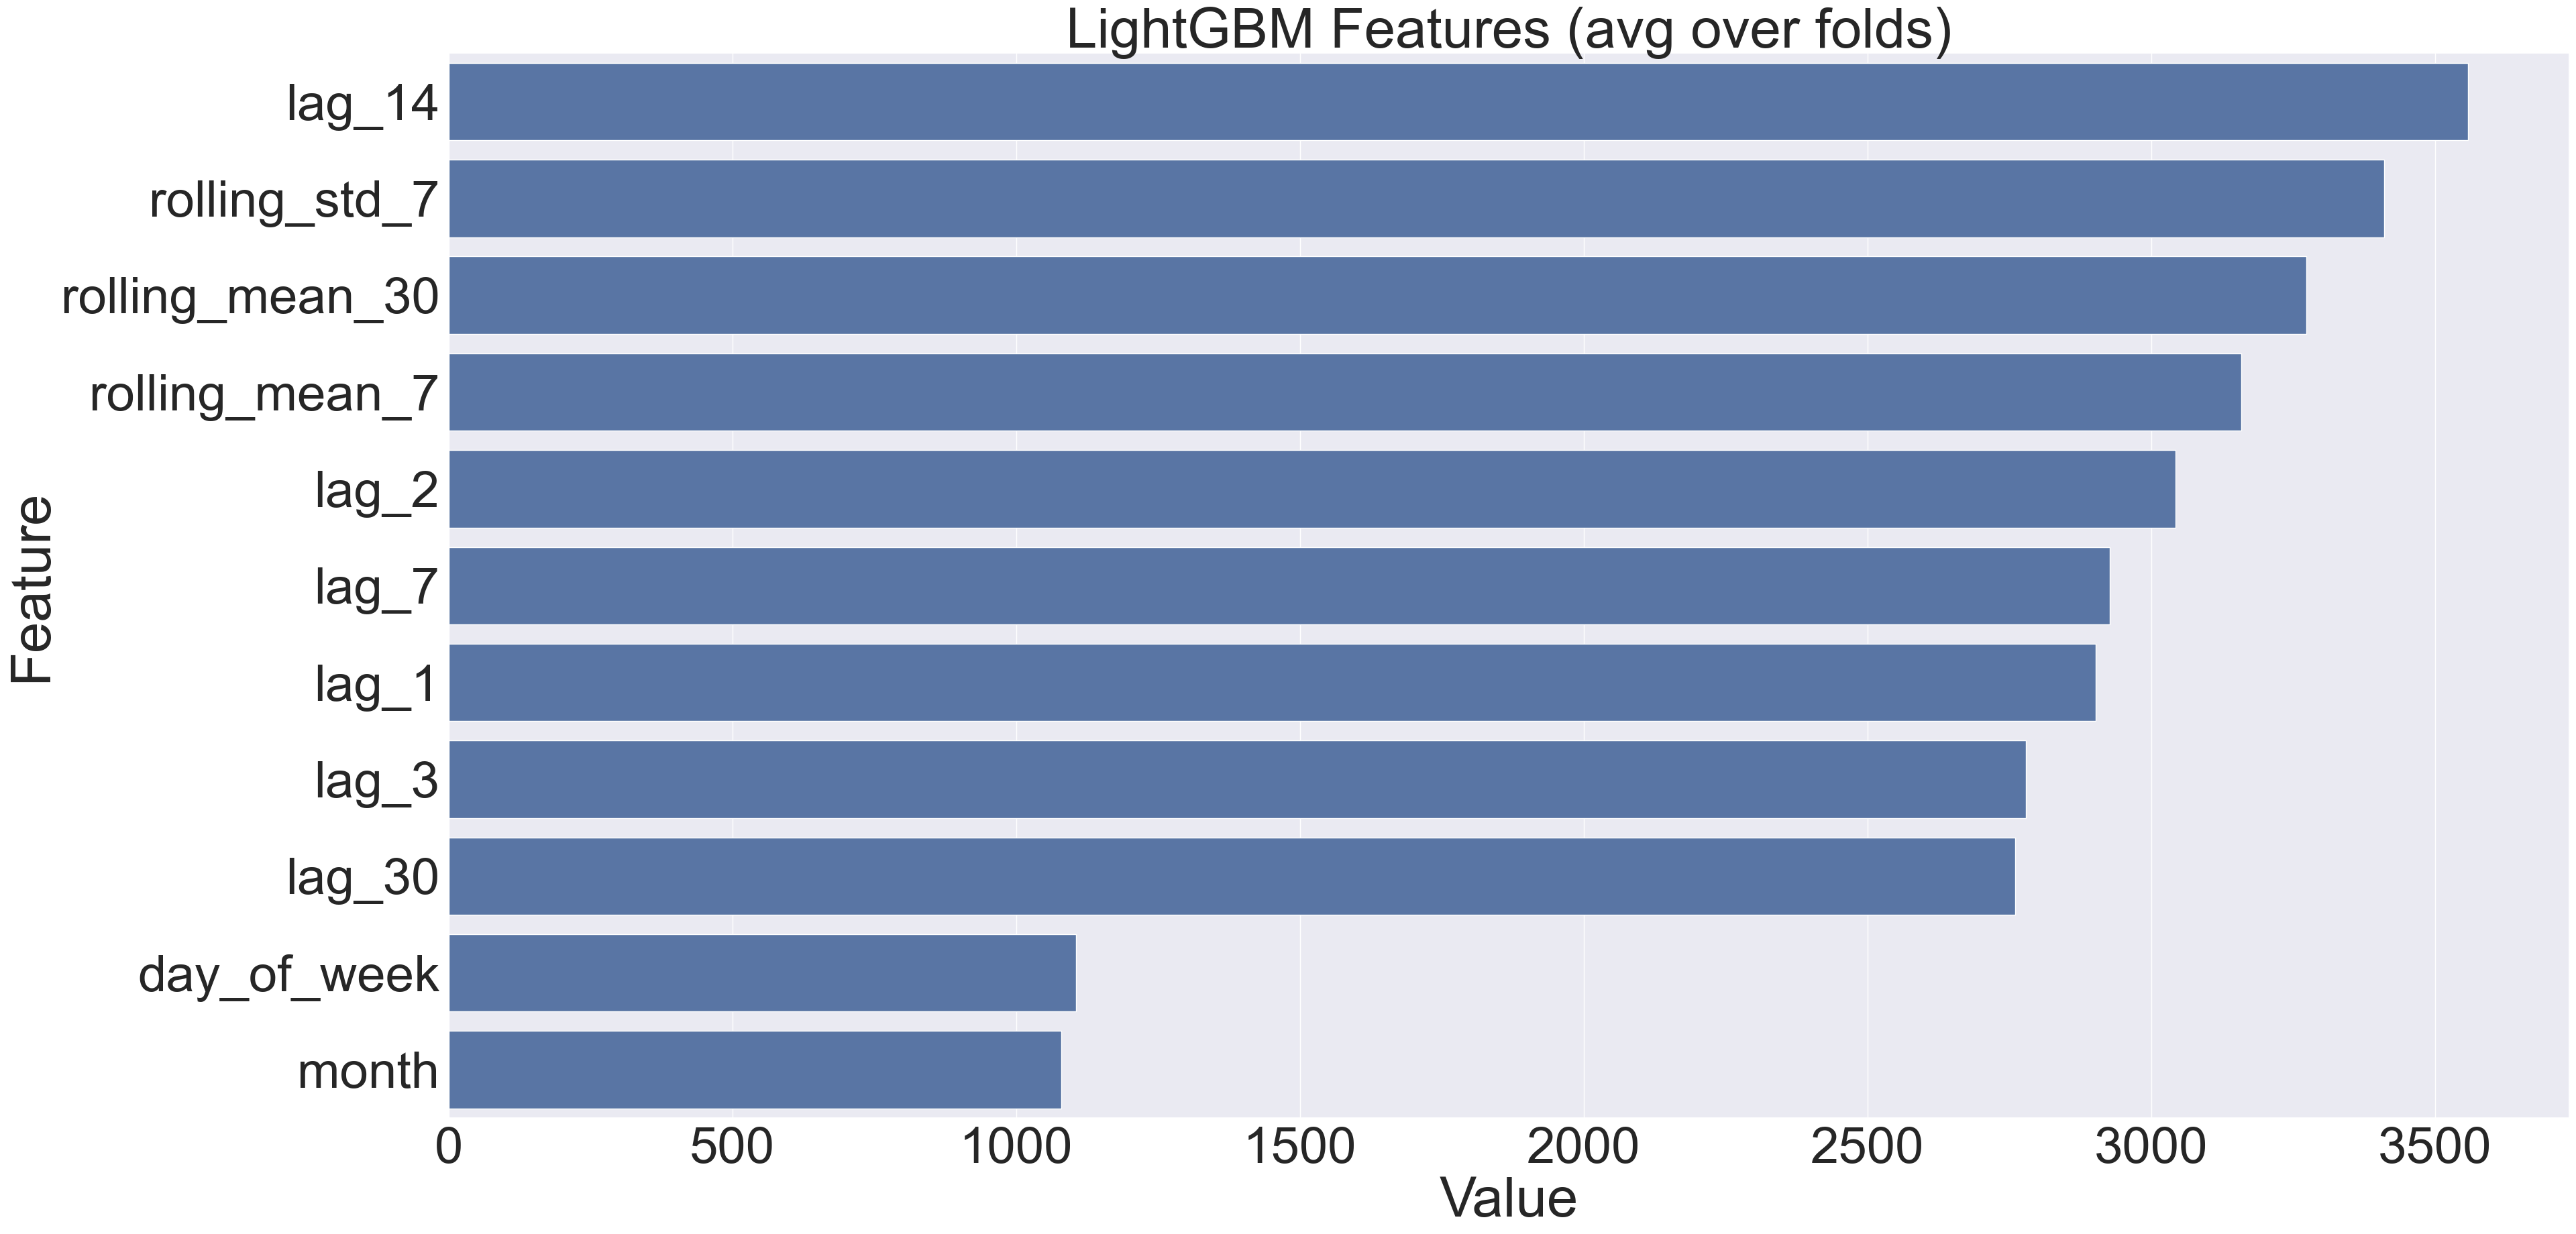

In [307]:
plotImp(model, X_train)

In [308]:
preds = model.predict(X_test)

In [309]:
print(preds)

[23.87673883 30.32615739 26.46953532 39.39753937 25.52189961 21.98378296
 29.58088816 18.5229047  28.40223154 30.56685382 33.06031212 10.8975031
 33.73304272 25.29243746 29.531865   20.89433844 25.72932777 28.50595197
 22.25857687 32.01299506 18.83812587  9.07366287 29.66158334 25.43647249
 28.37503137 20.40497297 32.91840477  4.21561298 34.89590358 25.58530667
 32.23767879 32.56513472 21.55233893 25.73188831 43.82815175 13.3296723
 27.89192287 23.47021498 27.19696778 14.9163764  19.016067   24.82794529
 23.04549057 16.10056147 34.42741581 15.81508158 28.3662992  28.80877205
 20.81235629 35.53224158 17.69085142 33.23451626 24.69002618 31.53303674
 30.47023333 24.69551701 20.14072902 35.96019057 28.1355907  25.62947693
 32.4993335  24.76397368 28.82681227 29.30079289 31.71273337 13.99497802
 28.09438651 14.40716655 25.74401668 30.35362046 43.20560883 31.5014489
 21.00732464 29.86084148 12.94718006 27.1387555  34.22247196  4.94872105
 23.78827196 25.85645362 24.02664274 32.91723317 22.62

In [310]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

print(rmse)

7.0187700267103885


In [311]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    preds
)

print(mae)

5.37907463437901


In [312]:
from sklearn.metrics import mean_absolute_percentage_error

mask = y_test > 0.1

mape = mean_absolute_percentage_error(
    y_test[mask],
    preds[mask]
)
mape

0.30040935016869763